# 11 — Neural-augmented reduced bases and temporal attention

RomApplication computes POD bases from solve snapshots; this application puts torch/physicsnemo
models on top of them:

1. a conductivity sweep of **real thermal solves** feeds `CalculateRomBasisOutputProcess`
   (numpy-SVD fallback in the same file layout when RomApplication is not compiled),
2. `rom_bridge` loads the basis and a small MLP learns conductivity → reduced coordinates `q`,
   deployed at an unseen conductivity by `RomSurrogateProcess` (`u = Φq` full-field
   reconstruction),
3. `rom_temporal` trains physicsnemo's decoder-only attention (`Sequence_Model`) on ROM
   **trajectories** — mesh-reduced temporal attention in ROM space — and rolls it out
   autoregressively.

Needs `ConvectionDiffusionApplication` + `LinearSolversApplication` compiled; RomApplication is
optional (fallback shown).


In [1]:
from pathlib import Path

import numpy
import torch
import matplotlib.pyplot as plt

import KratosMultiphysics as Kratos
import KratosMultiphysics.kratos_utilities as kratos_utils

assert kratos_utils.CheckIfApplicationsAvailable(
    "ConvectionDiffusionApplication", "LinearSolversApplication"), \
    "This notebook needs ConvectionDiffusionApplication and LinearSolversApplication compiled."
HAVE_ROM_APPLICATION = kratos_utils.CheckIfApplicationsAvailable("RomApplication")
print("RomApplication available:", HAVE_ROM_APPLICATION)

import KratosMultiphysics.ConvectionDiffusionApplication  # registers the thermal variables
from KratosMultiphysics.ConvectionDiffusionApplication.convection_diffusion_analysis import ConvectionDiffusionAnalysis
from KratosMultiphysics.PhysicsNeMoApplication.bridges import rom_bridge
from KratosMultiphysics.PhysicsNeMoApplication.training import rom_temporal, training_utils
from KratosMultiphysics import pyvista_utilities as pv_utils

OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)
DIVISIONS = 8

_VARIABLES = ("TEMPERATURE", "DENSITY", "SPECIFIC_HEAT", "CONDUCTIVITY", "HEAT_FLUX",
              "FACE_HEAT_FLUX", "PROJECTED_SCALAR1", "CONVECTION_VELOCITY",
              "TEMPERATURE_GRADIENT", "TRANSFER_COEFFICIENT", "REACTION",
              "VELOCITY", "MESH_VELOCITY", "REACTION_FLUX")

_PROJECT_PARAMETERS = '''{
    "problem_data": { "problem_name": "rom_thermal", "parallel_type": "OpenMP",
                      "start_time": 0.0, "end_time": 0.99, "echo_level": 0 },
    "solver_settings": {
        "solver_type": "stationary", "analysis_type": "linear",
        "model_part_name": "ThermalModelPart", "domain_size": 2,
        "model_import_settings": { "input_type": "use_input_model_part" },
        "material_import_settings": { "materials_filename": "" },
        "echo_level": 0,
        "problem_domain_sub_model_part_list": ["Domain"],
        "processes_sub_model_part_list": [],
        "convection_diffusion_variables": {
            "unknown_variable": "TEMPERATURE", "density_variable": "DENSITY",
            "specific_heat_variable": "SPECIFIC_HEAT", "diffusion_variable": "CONDUCTIVITY",
            "volume_source_variable": "HEAT_FLUX", "velocity_variable": "VELOCITY",
            "mesh_velocity_variable": "MESH_VELOCITY", "reaction_variable": "REACTION_FLUX"
        },
        "time_stepping": { "time_step": 1.0 }
    },
    "processes": {}, "output_processes": {}
}'''

def create_thermal_part(model):
    model_part = model.CreateModelPart("ThermalModelPart")
    model_part.ProcessInfo[Kratos.DOMAIN_SIZE] = 2
    model_part.SetBufferSize(2)
    for name in _VARIABLES:
        model_part.AddNodalSolutionStepVariable(Kratos.KratosGlobals.GetVariable(name))
    generator_geometry = Kratos.Quadrilateral2D4(
        Kratos.Node(1, 0.0, 0.0, 0.0), Kratos.Node(2, 0.0, 1.0, 0.0),
        Kratos.Node(3, 1.0, 1.0, 0.0), Kratos.Node(4, 1.0, 0.0, 0.0))
    domain = model_part.CreateSubModelPart("Domain")
    Kratos.StructuredMeshGeneratorProcess(generator_geometry, domain, Kratos.Parameters('''{
        "number_of_divisions": %d, "element_name": "Element2D3N",
        "condition_name": "LineCondition", "create_skin_sub_model_part": false
    }''' % DIVISIONS)).Execute()
    return model_part

def solve_thermal(conductivity):
    model = Kratos.Model()
    model_part = create_thermal_part(model)
    for node in model_part.Nodes:
        node.SetSolutionStepValue(Kratos.DENSITY, 1.0)
        node.SetSolutionStepValue(Kratos.SPECIFIC_HEAT, 1.0)
        node.SetSolutionStepValue(Kratos.CONDUCTIVITY, conductivity)
        node.SetSolutionStepValue(Kratos.HEAT_FLUX, 1.0)
        if min(node.X, node.Y, 1.0 - node.X, 1.0 - node.Y) < 1e-8:
            node.Fix(Kratos.TEMPERATURE)
    ConvectionDiffusionAnalysis(model, Kratos.Parameters(_PROJECT_PARAMETERS)).Run()
    return model, model_part

def temperatures(model_part):
    return numpy.array(Kratos.VariableUtils().GetSolutionStepValuesVector(
        model_part.Nodes, Kratos.TEMPERATURE, 0))

TRAIN_CONDUCTIVITIES = (0.5, 1.0, 2.0, 4.0)
snapshots = []
for k in TRAIN_CONDUCTIVITIES:
    _, part = solve_thermal(k)
    snapshots.append(temperatures(part))
snapshots = numpy.stack(snapshots, axis=1)   # (n_dofs, S)
node_ids = numpy.array([node.Id for node in part.Nodes])
print("snapshot matrix:", snapshots.shape)


RomApplication available: True
snapshot matrix: (81, 4)


## The POD basis

With RomApplication compiled, its real `CalculateRomBasisOutputProcess` computes and writes the
basis; without it, a plain numpy SVD writes the **same file layout** — either way `rom_bridge`
loads it identically (that is the point of consuming the *format*).


In [2]:
BASIS_FOLDER = OUTPUT / "rom_data"

if HAVE_ROM_APPLICATION:
    from KratosMultiphysics.RomApplication.calculate_rom_basis_output_process import CalculateRomBasisOutputProcess
    host_model = Kratos.Model()
    host_part = create_thermal_part(host_model)
    process = CalculateRomBasisOutputProcess(host_model, Kratos.Parameters('''{
        "model_part_name": "ThermalModelPart",
        "nodal_unknowns": ["TEMPERATURE"],
        "rom_basis_output_format": "numpy",
        "rom_basis_output_folder": "%s",
        "svd_truncation_tolerance": 1e-8,
        "print_singular_values": true
    }''' % BASIS_FOLDER))
    for column in range(snapshots.shape[1]):
        Kratos.VariableUtils().SetSolutionStepValuesVector(
            host_part.Nodes, Kratos.TEMPERATURE,
            Kratos.Vector(numpy.ascontiguousarray(snapshots[:, column])), 0)  # Vector ignores strides
        process.PrintOutput()
    process.ExecuteFinalize()
else:
    import json
    BASIS_FOLDER.mkdir(parents=True, exist_ok=True)
    phi, sigma, _ = numpy.linalg.svd(snapshots, full_matrices=False)
    keep = sigma > 1e-8 * sigma[0]
    numpy.save(BASIS_FOLDER / "RightBasisMatrix.npy", phi[:, keep])
    numpy.save(BASIS_FOLDER / "NodeIds.npy", node_ids)
    numpy.save(BASIS_FOLDER / "SingularValuesVector.npy", sigma[keep])
    (BASIS_FOLDER / "RomParameters.json").write_text(json.dumps({
        "rom_format": "numpy",
        "rom_settings": {"nodal_unknowns": ["TEMPERATURE"],
                         "number_of_rom_dofs": int(keep.sum())}}, indent=4))

basis = rom_bridge.LoadRomBasis(BASIS_FOLDER)
print(f"{basis.n_modes} mode(s) over {basis.n_nodes} nodes; singular values: {basis.singular_values}")

q_targets = rom_bridge.ProjectToReducedSpace(basis, snapshots)   # (n_modes, S)
worst = max(numpy.linalg.norm(basis.phi @ q_targets[:, i] - snapshots[:, i]) /
            numpy.linalg.norm(snapshots[:, i]) for i in range(snapshots.shape[1]))
print(f"worst training-snapshot reconstruction error: {worst:.2e}")


iter =  1  nC =  0.0016678591507560605  dR =  1.0  R =  1
reorthogonalizing
iter =  2  nC =  2.256634817728689e-06  dR =  1.0  R =  2
reorthogonalizing
iter =  3  nC =  7.035491520680528e-10  dR =  1.0  R =  3
3 mode(s) over 81 nodes; singular values: [6.93616175e-01 1.33975045e-03 7.35935238e-07]
worst training-snapshot reconstruction error: 2.83e-09


## Neural-augmented reduced basis: conductivity → q → full field

The surrogate only has to learn `n_modes` numbers per case. `TrainModel` fits the k → q map, and
`RomSurrogateProcess` deploys it: the parameter rides an ordinary nodal carrier field, the model
predicts `q`, and `u = Φq` is written onto `TEMPERATURE` — the model card check validates against
the basis's `nodal_unknowns` automatically.


In [3]:
from KratosMultiphysics.PhysicsNeMoApplication.processes.inference import rom_surrogate_process

torch.manual_seed(0)
surrogate = torch.nn.Sequential(
    torch.nn.Linear(1, 16), torch.nn.Tanh(), torch.nn.Linear(16, basis.n_modes)).double()
dataset = torch.utils.data.TensorDataset(
    torch.tensor([[k] for k in TRAIN_CONDUCTIVITIES], dtype=torch.float64),
    torch.tensor(q_targets.T, dtype=torch.float64))
history = training_utils.TrainModel(surrogate, dataset, Kratos.Parameters('''{
    "epochs": 2000, "batch_size": 4, "learning_rate": 5e-3,
    "device": "auto", "seed": 0, "echo_interval": 500
}'''))
print(f"loss: {history[0]:.3e} -> {history[-1]:.3e}")
checkpoint = OUTPUT / "k_to_q.pt"
torch.jit.script(surrogate).save(str(checkpoint))

TEST_CONDUCTIVITY = 1.5
model, model_part = solve_thermal(TEST_CONDUCTIVITY)
reference = temperatures(model_part)

carrier = Kratos.KratosGlobals.GetVariable("PROJECTED_SCALAR1")
for node in model_part.Nodes:
    node.SetSolutionStepValue(carrier, TEST_CONDUCTIVITY)

process = rom_surrogate_process.Factory(Kratos.Parameters('''{
    "Parameters": {
        "model_part_name":  "ThermalModelPart",
        "rom_basis_folder": "%s",
        "model_settings":   { "checkpoint_file": "%s", "device": "auto" },
        "input_fields":     [ { "variable_name": "PROJECTED_SCALAR1", "data_location": "node_historical" } ]
    }
}''' % (BASIS_FOLDER, checkpoint)), model)
model_part.ProcessInfo[Kratos.STEP] = 1
process.ExecuteFinalizeSolutionStep()

predicted = temperatures(model_part)
rel_error = numpy.linalg.norm(predicted - reference) / numpy.linalg.norm(reference)
print(f"held-out k = {TEST_CONDUCTIVITY}: relative error vs the real solve = {rel_error:.2e}")


loss: 3.963e-01 -> 2.177e-05
held-out k = 1.5: relative error vs the real solve = 3.58e-02


## Visualizing the reconstructed field

`rom_surrogate_process` reconstructs the full-order `TEMPERATURE` field in place from the surrogate's modal coefficients. The real solve (captured beforehand into `NODAL_PAUX`), the reconstructed surrogate field, and their difference are rendered on the actual mesh with the core pyvista bridge (`KratosMultiphysics.pyvista_utilities`).

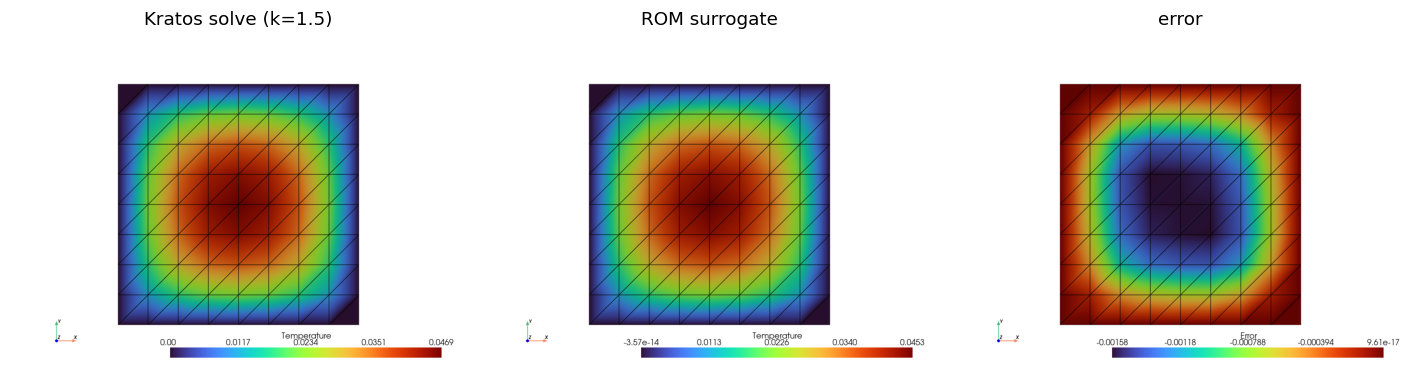

In [4]:
for node, value in zip(model_part.Nodes, reference):
    node.SetValue(Kratos.NODAL_PAUX, float(value))
for node, value in zip(model_part.Nodes, predicted - reference):
    node.SetValue(Kratos.NODAL_ERROR, float(value))

panels = [
    (Kratos.NODAL_PAUX,  f"Kratos solve (k={TEST_CONDUCTIVITY})", "Temperature"),
    (Kratos.TEMPERATURE, "ROM surrogate",                         "Temperature"),
    (Kratos.NODAL_ERROR, "error",                                  "Error"),
]
images = [
    pv_utils.ScreenshotModelPart(model_part, filename=None, name=variable,
                                 label=label, cmap="turbo")
    for variable, _, label in panels
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, img, (_, title, _) in zip(axes, images, panels):
    ax.imshow(img); ax.set_title(title); ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT / "rom_field_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## Temporal attention in ROM space

For transient problems the reduced coordinates become trajectories `q(t)`. physicsnemo's
decoder-only attention (`Sequence_Model`) learns those dynamics directly in ROM space — here on a
synthetic family of damped-oscillation trajectories seeded from the basis modes (each context is
the trajectory's decay rate). A context token is always fed; training is teacher-forced and
rollout autoregressive.


In [5]:
rng = numpy.random.default_rng(0)
STEPS, SAMPLES = 16, 24
decay_rates = rng.uniform(0.05, 0.25, SAMPLES)
trajectories = []
for rate in decay_rates:
    q0 = q_targets[:, rng.integers(q_targets.shape[1])]
    t = numpy.arange(STEPS)[:, None]
    trajectories.append(q0 * numpy.exp(-rate * t) * numpy.cos(0.4 * t))
trajectories = numpy.stack(trajectories)          # (S, T, M)

temporal = rom_temporal.CreateSequenceModel(Kratos.Parameters('''{
    "input_dim": %d, "num_layers_decoder": 2, "num_heads": 1, "device": "auto"
}''' % basis.n_modes))
dataset = rom_temporal.CreateRomTrajectoryDataset(trajectories, decay_rates[:, None])
history = rom_temporal.TrainRomTemporalModel(temporal, dataset, Kratos.Parameters('''{
    "epochs": 300, "batch_size": 8, "learning_rate": 1e-3,
    "device": "auto", "seed": 0, "echo_interval": 100
}'''))
print(f"loss: {history[0]:.3e} -> {history[-1]:.3e}")

# held-out trajectory: prompt with its first 4 states, roll the remaining 12
test_rate = 0.15
t = numpy.arange(STEPS)[:, None]
truth = q_targets[:, 0] * numpy.exp(-test_rate * t) * numpy.cos(0.4 * t)
rollout = rom_temporal.PredictRomTrajectory(
    temporal, truth[:4], steps=STEPS - 4, context=numpy.array([test_rate]))
rollout_rmse = float(numpy.sqrt(numpy.mean((rollout[4:] - truth[4:]) ** 2)))
print(f"autoregressive rollout rmse (q space): {rollout_rmse:.4f}  "
      f"(trajectory scale {numpy.abs(truth).max():.3f})")

# reconstruct the predicted trajectory to full-order fields
fields = rom_bridge.ReconstructFromReducedSpace(basis, rollout.T)   # (n_dofs, T)
print("reconstructed field series:", fields.shape)

rom_temporal.SaveRomTemporalModel(temporal, Kratos.Parameters('''{
    "input_dim": %d, "num_layers_decoder": 2, "num_heads": 1, "device": "auto"
}''' % basis.n_modes), OUTPUT / "rom_temporal.pt")


/home/vicente/src/Kratos/bin/Release/KratosMultiphysics/PhysicsNeMoApplication/rom_temporal.py:219: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  epoch_loss += float(loss)
loss: 1.682e-02 -> 3.836e-04
autoregressive rollout rmse (q space): 0.0568  (trajectory scale 0.594)
reconstructed field series: (81, 16)


## Where to go from here

- Real transient dynamics: export solve series with `DatasetExportProcess`, project each series
  with `ProjectToReducedSpace(basis, series)` and train on the resulting `(T, M)` trajectories.
- `Sequence_Model` checkpoints only via `Save/LoadRomTemporalModel` (state_dict + settings) — it
  is neither TorchScript-scriptable nor a physicsnemo `Module`.
- Petrov–Galerkin / HROM bases from the RomManager write the same numpy layout; `rom_bridge`
  consumes them unchanged.
